# 02 · Construcción de datasets temporales

Este notebook transforma el histórico jugador-partido en un dataset prepartido donde cada fila representa el encuentro cuyo rendimiento se quiere predecir. Para respetar el carácter temporal del problema, el objetivo se denomina `PIR_target` y todas las medias históricas utilizan `shift(1)`, de modo que nunca incorporan información del propio partido objetivo.

La población modelable exige al menos tres apariciones previas y una media mínima de cinco minutos durante las diez apariciones anteriores. Esta regla proporciona suficiente historia para calcular las variables recientes y, al mismo tiempo, conserva una muestra amplia. Su efecto sobre los perfiles retenidos y excluidos se cuantifica posteriormente en el notebook 07.

In [1]:
from pathlib import Path
import platform
import re
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def find_project_root(start=Path.cwd()):
    for candidate in [start, *start.parents]:
        if (candidate / "data" / "raw").is_dir() and (candidate / "reports").is_dir():
            return candidate
    raise FileNotFoundError("No se encontró el raíz del proyecto (data/raw y reports).")

ROOT = find_project_root()
RAW_DIR = ROOT / "data" / "raw"
PROCESSED_DIR = ROOT / "data" / "processed"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
pd.set_option("display.max_columns", 100)
plt.style.use("seaborn-v0_8-whitegrid")
print({"root": str(ROOT), "python": sys.version.split()[0], "pandas": pd.__version__, "platform": platform.platform()})

TABLE_DIR = ROOT / "reports" / "tables" / "02_dataset"
FIGURE_DIR = ROOT / "reports" / "figures" / "02_dataset"
TABLE_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

clean_path = PROCESSED_DIR / "player_game_clean_1718.csv"
if not clean_path.exists():
    raise FileNotFoundError("Ejecuta primero 01_eda_y_limpieza.ipynb")
clean = pd.read_csv(clean_path, parse_dates=["Date"])
assert len(clean) == 10_577, f"Filas limpias inesperadas: {len(clean)}"
assert not clean["Player"].astype(str).str.strip().str.lower().isin({"equipo", "team"}).any()
print({"input_rows": len(clean), "players": clean["player_id"].nunique()})

{'root': 'C:\\Users\\pablo\\OneDrive\\Documentos\\TFM\\tfm-scouting-ml-dl', 'python': '3.12.4', 'pandas': '2.2.2', 'platform': 'Windows-10-10.0.19045-SP0'}
{'input_rows': 10577, 'players': 868}


## Ingeniería de variables históricas

Las variables históricas resumen lo ocurrido en los últimos cinco o diez partidos del jugador. Antes de calcular cada media se aplica `shift(1)`, que desplaza la información una fila y garantiza que el partido que se quiere predecir no entre en sus propios predictores. Los indicadores de eficiencia se calculan primero para cada actuación y después se resumen a lo largo del tiempo.

In [2]:
NUMERIC_STATS = ["PIR", "PTS", "AST", "TOV", "TRB", "ORB", "DRB", "STL", "PF", "PFrv", "TwoP", "TwoPA", "ThreeP", "ThreePA", "FT", "FTA", "BLKfv", "BLKag", "Dunks"]
ROLLING_BASE = ["MP_min", "PIR", "PTS", "AST", "TOV", "TRB", "ORB", "DRB", "STL", "PF", "FGA", "FTA", "eFG", "TS", "FT_rate", "3P_rate", "AST_TOV"]

def add_boxscore_features(frame):
    out = frame.copy()
    for column in NUMERIC_STATS:
        out[column] = pd.to_numeric(out[column], errors="coerce")
    out["FGA"] = out["TwoPA"] + out["ThreePA"]
    out["eFG"] = np.where(out["FGA"] > 0, (out["TwoP"] + 1.5 * out["ThreeP"]) / out["FGA"], np.nan)
    denom = 2 * (out["FGA"] + 0.44 * out["FTA"])
    out["TS"] = np.where(denom > 0, out["PTS"] / denom, np.nan)
    out["FT_rate"] = np.where(out["FGA"] > 0, out["FTA"] / out["FGA"], np.nan)
    out["3P_rate"] = np.where(out["FGA"] > 0, out["ThreePA"] / out["FGA"], np.nan)
    out["AST_TOV"] = np.where(out["TOV"] > 0, out["AST"] / out["TOV"], np.nan)
    return out

def add_shifted_rolling(frame, windows=(5, 10)):
    out = frame.sort_values(["player_id", "Date", "match_id"]).copy()
    group = out.groupby("player_id", sort=False)
    for window in windows:
        minimum = max(3, window // 2)
        for column in ROLLING_BASE:
            out[f"{column}_roll{window}"] = group[column].transform(
                lambda s, w=window, m=minimum: s.shift(1).rolling(w, min_periods=m).mean()
            )
            out[f"{column}_roll{window}_count"] = group[column].transform(
                lambda s, w=window: s.shift(1).rolling(w, min_periods=1).count()
            )
    return out

boxscore = add_boxscore_features(clean)

## Registro de variables derivadas

Además de estadísticas directas —PIR, puntos, asistencias o rebotes— se construyen cinco indicadores de uso y eficiencia. Cuando un denominador es cero, el cociente queda como ausente en lugar de asignarle un valor deportivo artificial. La imputación, si resulta necesaria, se realizará posteriormente dentro del train de cada fold.

In [3]:
derived_registry = pd.DataFrame([
    {"feature": "FGA", "meaning": "Tiros de campo intentados", "formula": "TwoPA + ThreePA", "zero_denominator": "not applicable"},
    {"feature": "eFG", "meaning": "Porcentaje efectivo de tiro", "formula": "(TwoP + 1.5 * ThreeP) / FGA", "zero_denominator": "NaN"},
    {"feature": "TS", "meaning": "True shooting", "formula": "PTS / (2 * (FGA + 0.44 * FTA))", "zero_denominator": "NaN"},
    {"feature": "FT_rate", "meaning": "Frecuencia de tiros libres", "formula": "FTA / FGA", "zero_denominator": "NaN"},
    {"feature": "3P_rate", "meaning": "Proporción de triples", "formula": "ThreePA / FGA", "zero_denominator": "NaN"},
    {"feature": "AST_TOV", "meaning": "Relación asistencias/pérdidas", "formula": "AST / TOV", "zero_denominator": "NaN"},
])
derived_registry.to_csv(TABLE_DIR / "derived_feature_registry.csv", index=False)
display(derived_registry)

,feature,meaning,formula,zero_denominator
0,FGA,Tiros de campo intentados,TwoPA + ThreePA,not applicable
1,eFG,Porcentaje efectivo de tiro,(TwoP + 1.5 * ThreeP) / FGA,NaN
2,TS,True shooting,PTS / (2 * (FGA + 0.44 * FTA)),NaN
3,FT_rate,Frecuencia de tiros libres,FTA / FGA,NaN
4,3P_rate,Proporción de triples,ThreePA / FGA,NaN
5,AST_TOV,Relación asistencias/pérdidas,AST / TOV,NaN


## Alineación con el partido objetivo y elegibilidad

Primero se asigna a cada fila su fecha y PIR objetivo. Después se calculan los días desde la aparición anterior y se aplica la regla 3/5. El filtrado se realiza después de construir la historia para no perder partidos anteriores útiles.

In [4]:
def target_population(frame):
    out = frame.sort_values(["competition", "player_id", "Date", "match_id"]).copy()
    out["target_date"] = out["Date"]
    out["PIR_target"] = out["PIR"]
    out["previous_appearance_date"] = out.groupby("player_id", sort=False)["Date"].shift(1)
    out["rest_days_player"] = (out["target_date"] - out["previous_appearance_date"]).dt.days
    return add_shifted_rolling(out)

def apply_eligibility(frame, min_appearances, min_prior_minutes):
    out = frame.sort_values(["player_id", "Date", "match_id"]).copy()
    group = out.groupby("player_id", sort=False)
    prior_count = group["MP_min"].transform(lambda s: s.shift(1).rolling(10, min_periods=1).count())
    prior_minutes = group["MP_min"].transform(lambda s: s.shift(1).rolling(10, min_periods=1).mean())
    out["eligibility_prior_appearances"] = prior_count
    out["eligibility_prior_minutes_mean10"] = prior_minutes
    return out[(prior_count >= min_appearances) & (prior_minutes >= min_prior_minutes - 1e-12)].copy()

target_all = target_population(boxscore)
target_3_5 = apply_eligibility(target_all, 3, 5)

assert len(target_3_5) == 7_269, f"Filas modelables inesperadas: {len(target_3_5)}"
assert target_3_5["player_id"].nunique() == 712, "Número de jugadores inesperado"
print({"rows": len(target_3_5), "players": target_3_5["player_id"].nunique()})

{'rows': 7269, 'players': 712}


## Controles antifuga y descripción de la población final

La igualdad entre fecha de fila y `target_date` es intencionada. `PIR_target` no se utilizará como predictor. Las columnas rolling se han calculado antes del filtrado para que la historia represente la población completa de apariciones.

In [5]:
assert target_3_5["target_date"].equals(target_3_5["Date"])
assert (target_3_5["eligibility_prior_appearances"] >= 3).all()
assert (target_3_5["eligibility_prior_minutes_mean10"] >= 5 - 1e-12).all()
dated_history = target_3_5.dropna(subset=["previous_appearance_date"])
assert (dated_history["previous_appearance_date"] < dated_history["target_date"]).all()
assert not target_3_5.duplicated(["competition", "match_id", "Team", "player_id"]).any()

MODEL_FEATURES = [
    "competition",
    *sorted(column for column in target_3_5.columns if "_roll" in column and not column.endswith("_count")),
    "rest_days_player",
]
FORBIDDEN = {"PIR", "PIR_target", "Date", "target_date", "days_to_next_game", "MP_min"}
assert len(MODEL_FEATURES) == 36
assert not FORBIDDEN.intersection(MODEL_FEATURES)
assert not any(column.endswith("_count") for column in MODEL_FEATURES)

flow = pd.DataFrame([
    {"stage": "clean_player_game", "rows": len(target_all), "players": target_all.player_id.nunique()},
    {"stage": "eligible_target_game_3_5", "rows": len(target_3_5), "players": target_3_5.player_id.nunique()},
])

population_all = target_all.groupby("competition").size().rename("candidate_rows")
population_eligible = target_3_5.groupby("competition").size().rename("eligible_rows")
eligibility_impact = pd.concat([population_all, population_eligible], axis=1).fillna(0).astype(int).reset_index()
eligibility_impact["excluded_rows"] = eligibility_impact["candidate_rows"] - eligibility_impact["eligible_rows"]
eligibility_impact["retained_pct"] = eligibility_impact["eligible_rows"] / eligibility_impact["candidate_rows"] * 100

by_competition = (target_3_5.groupby("competition")
                  .agg(rows=("player_id", "size"), players=("player_id", "nunique"),
                       pir_mean=("PIR_target", "mean"), pir_std=("PIR_target", "std"),
                       date_min=("target_date", "min"), date_max=("target_date", "max"))
                  .reset_index())

feature_registry = pd.DataFrame([
    {"family": "rolling_mean", "source": col, "window": window, "uses_current_target_game": False, "formula": f"shift(1).rolling({window}).mean()"}
    for window in (5, 10) for col in ROLLING_BASE
])
model_feature_manifest = pd.DataFrame({
    "feature": MODEL_FEATURES,
    "type": ["categorical" if column == "competition" else "numeric" for column in MODEL_FEATURES],
    "available_before_target": True,
    "included_in_models": True,
})

temporal_checks = pd.DataFrame([
    {"check": "target_date_equals_row_date", "passed": target_3_5["target_date"].equals(target_3_5["Date"])},
    {"check": "previous_appearance_strictly_before_target", "passed": bool((dated_history["previous_appearance_date"] < dated_history["target_date"]).all())},
    {"check": "minimum_three_prior_appearances", "passed": bool((target_3_5["eligibility_prior_appearances"] >= 3).all())},
    {"check": "minimum_five_prior_minutes", "passed": bool((target_3_5["eligibility_prior_minutes_mean10"] >= 5 - 1e-12).all())},
    {"check": "unique_target_key", "passed": not target_3_5.duplicated(["competition", "match_id", "Team", "player_id"]).any()},
    {"check": "model_features_exclude_target_and_counts", "passed": not FORBIDDEN.intersection(MODEL_FEATURES) and not any(column.endswith("_count") for column in MODEL_FEATURES)},
])
assert temporal_checks["passed"].all()

for filename, table in {
    "final_population_by_competition.csv": by_competition,
    "rows_flow.csv": flow,
    "eligibility_impact_by_competition.csv": eligibility_impact,
    "feature_registry.csv": feature_registry,
    "model_feature_manifest.csv": model_feature_manifest,
    "temporal_checks.csv": temporal_checks,
}.items():
    table.to_csv(TABLE_DIR / filename, index=False)
display(flow, eligibility_impact, by_competition, temporal_checks)

,stage,rows,players
0,clean_player_game,10577,868
1,eligible_target_game_3_5,7269,712


,competition,candidate_rows,eligible_rows,excluded_rows,retained_pct
0,acb,3633,2622,1011,72.171759
1,eurocup,3316,2095,1221,63.178528
2,euroleague,3628,2552,1076,70.341786


,competition,rows,players,pir_mean,pir_std,date_min,date_max
0,acb,2622,222,7.757437,7.617920,2017-10-14,2018-01-21
1,eurocup,2095,287,8.362291,8.464094,2017-10-31,2018-01-17
2,euroleague,2552,203,8.232759,8.020792,2017-10-26,2018-01-19


,check,passed
0,target_date_equals_row_date,True
1,previous_appearance_strictly_before_target,True
2,minimum_three_prior_appearances,True
3,minimum_five_prior_minutes,True
4,unique_target_key,True
5,model_features_exclude_target_and_counts,True


## Exportación del dataset definitivo y figura reproducible

El CSV resultante es la única entrada que utilizarán los notebooks de modelado. Se exportan tanto la población final como el efecto de la elegibilidad por competición. Las tablas fuente permiten recrear ambas figuras en Power BI.

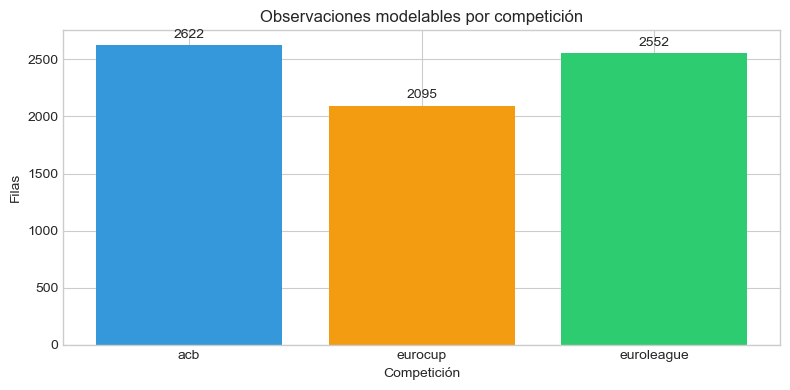

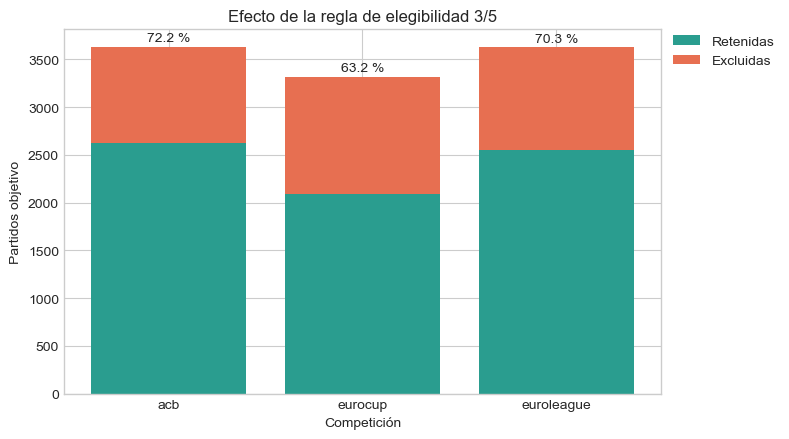

Dataset adoptado: C:\Users\pablo\OneDrive\Documentos\TFM\tfm-scouting-ml-dl\data\processed\player_pregame_target_game_3_5_1718.csv


In [6]:
target_3_5.to_csv(PROCESSED_DIR / "player_pregame_target_game_3_5_1718.csv", index=False, date_format="%Y-%m-%d")
by_competition.to_csv(TABLE_DIR / "figure_final_population_source.csv", index=False)

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(by_competition["competition"], by_competition["rows"], color=["#3498db", "#f39c12", "#2ecc71"])
ax.bar_label(bars, fmt="%d", padding=3)
ax.set(title="Observaciones modelables por competición", xlabel="Competición", ylabel="Filas")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "final_population_by_competition.png", dpi=160, bbox_inches="tight")
plt.show()

eligibility_impact.to_csv(TABLE_DIR / "figure_eligibility_impact_source.csv", index=False)
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(eligibility_impact["competition"], eligibility_impact["eligible_rows"], label="Retenidas", color="#2a9d8f")
ax.bar(eligibility_impact["competition"], eligibility_impact["excluded_rows"],
       bottom=eligibility_impact["eligible_rows"], label="Excluidas", color="#e76f51")
for index, row in eligibility_impact.iterrows():
    ax.text(index, row["candidate_rows"] + 60, f'{row["retained_pct"]:.1f} %', ha="center")
ax.set(title="Efecto de la regla de elegibilidad 3/5", xlabel="Competición", ylabel="Partidos objetivo")
ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1), borderaxespad=0)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "eligibility_impact_by_competition.png", dpi=160, bbox_inches="tight")
plt.show()

evidence_catalog = pd.DataFrame([
    {"artifact": "eligibility_impact_by_competition.png", "priority": "principal", "question": "¿Qué efecto tiene la elegibilidad sobre la población?", "source_csv": "figure_eligibility_impact_source.csv"},
    {"artifact": "final_population_by_competition.png", "priority": "principal", "question": "¿Cómo se distribuye el dataset modelable?", "source_csv": "figure_final_population_source.csv"},
    {"artifact": "model_feature_manifest.csv", "priority": "control", "question": "¿Qué variables podrán entrar en los modelos?", "source_csv": "model_feature_manifest.csv"},
    {"artifact": "temporal_checks.csv", "priority": "control", "question": "¿Qué invariantes temporales se verificaron?", "source_csv": "temporal_checks.csv"},
])
evidence_catalog.to_csv(TABLE_DIR / "evidence_catalog.csv", index=False)
print("Dataset adoptado:", PROCESSED_DIR / "player_pregame_target_game_3_5_1718.csv")

## Conclusión

La ejecución genera un dataset definitivo de 7.269 observaciones correspondientes a 712 jugadores. Todas las variables temporales terminan antes del partido objetivo y el manifiesto limita la entrada de los modelos a 36 predictores, excluyendo identificadores, fechas, recuentos auxiliares, estadísticas actuales y `PIR_target`.

La elegibilidad aporta la historia mínima necesaria para representar la forma reciente, pero no significa que las actuaciones excluidas carezcan de relevancia deportiva ni permite generalizar el modelo a jugadores sin ese historial. El notebook 07 muestra que la población retenida acumula, en promedio, más minutos, PIR y apariciones observadas, por lo que esta diferencia se conserva como limitación explícita del alcance del estudio.